# ARTI 308 – Lab 5: Feature Engineering (Classification)
## Order Status Prediction using a Talabat-style Orders Dataset

### Lab focus
This dataset is already clean (no missing values, no duplicate rows, consistent data types).  
In this lab, we focus on **feature engineering** for a classification task, not on data cleaning.

### Objective
Build a baseline model to predict `Order_Status` (Delivered, Cancelled, In Transit) and learn how feature engineering choices affect model performance and feature importance.

In this lab we will:
1) Load and inspect the dataset  
2) Define the target and select usable predictors (avoid leakage features)  
3) Engineer new features (time-based, price-based, distance-based)  
4) Encode categorical features  
5) Train a baseline **Random Forest** classifier  
6) Interpret performance and feature importance  

## 1. Setup and imports

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load the dataset

In [39]:
DATA_PATH = "/content/talabat_enhanced_orders.csv"  # ensure the file is in the same folder as this notebook
df = pd.read_csv(DATA_PATH)

df.head(10)


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,Alexandria,Wallet,Delivered,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,Zagazig,Credit Card,Delivered,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,Assiut,Cash,In Transit,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,Mansoura,Cash,Delivered,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,Mansoura,Wallet,Delivered,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online
5,6,U7439,750,270,Sushi,3,205.44,2025-06-04 12:16:00,2025-06-04 12:45:00,29,Mansoura,Credit Card,Delivered,Bicycle,31.024140,31.387817,31.029004,31.373869,31.022573,31.380646,1.436807,Medium,Online
6,7,U8948,827,4,Sushi,1,133.94,2025-06-11 04:09:00,2025-06-11 04:49:00,40,Cairo,Wallet,Delivered,Bicycle,30.026723,31.249101,30.043525,31.233372,30.038769,31.231835,2.402167,Low,Online
7,8,U8672,908,109,Shawarma,5,404.80,2025-06-12 18:37:00,2025-06-12 19:18:00,41,Mansoura,Cash,Delivered,Bicycle,31.052547,31.392976,31.053352,31.362834,31.049187,31.373710,2.878434,High,Online
8,9,U2205,814,215,Pizza,1,101.03,2025-06-01 22:18:00,2025-06-01 23:05:00,47,Mansoura,Credit Card,Delivered,Motorbike,31.041945,31.375128,31.041036,31.385503,31.041062,31.368488,0.995562,Low,Online
9,10,U7411,362,416,Pizza,1,130.05,2025-06-09 00:18:00,2025-06-09 01:04:00,46,Cairo,Wallet,Delivered,Bicycle,30.052723,31.236077,30.025107,31.229281,30.062032,31.227642,3.130713,Low,Online


The first rows confirm that the dataset loaded correctly.  
Each row represents one food delivery order, including information about the customer, restaurant, driver, and order outcome (`Order_Status`).

## 3. Quick dataset checks (cleanliness confirmation)

In [40]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (100000, 23)

Missing values per column:


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


We confirm the dataset is clean: no missing values and no duplicated rows.  
Therefore, we will spend our effort on feature engineering rather than cleaning.

## 4. Target variable and class balance

In [41]:
target_col = "Order_Status"
df[target_col].value_counts()

,count
Order_Status,
Delivered,85197
Cancelled,9812
In Transit,4991


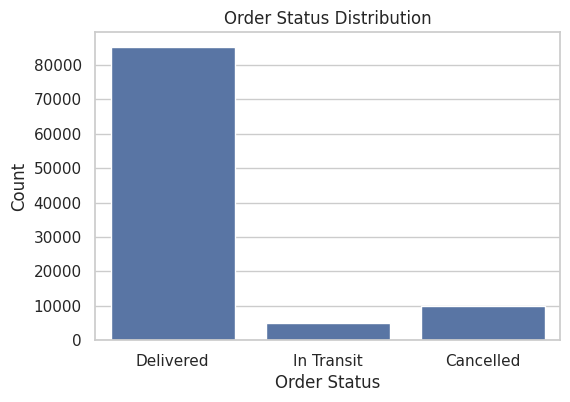

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

This bar chart shows whether the classes are balanced.  
If one class dominates, the model may learn to predict that class more often, so we must interpret accuracy carefully and also look at the confusion matrix.

## 5. Identify feature types

In [43]:
df.dtypes

,0
Order_ID,int64
User_ID,object
Restaurant_ID,int64
Driver_ID,int64
Item_Name,object
Quantity,int64
Total_Price,float64
Order_Time,object
Delivery_Time,object
Delivery_Duration_Minutes,int64


We have a mixture of numerical features (e.g., `Quantity`, `Total_Price`, distances) and categorical features (e.g., `City`, `Payment_Method`, `Traffic_Level`).  
This is a common real-world situation where feature engineering and encoding become essential.


## 6. Leakage awareness (important)

When designing a prediction task, we must avoid using features that would not be available at prediction time.

For example, if we want to predict the order status **right after the customer places the order**, we should not use:
- `Delivery_Time` (known only later)
- `Delivery_Duration_Minutes` (known only after delivery)

In this lab, we will **exclude** obvious leakage features and focus on information that is typically available early in the order lifecycle.


## 7. Feature engineering

### 7.1 Time-based features from `Order_Time`
We convert `Order_Time` into a datetime, then extract:
- hour of day  
- day of week  
- weekend flag  
- peak hour flag (example rule: lunch and dinner periods)


In [44]:
df_fe = df.copy()

# Parse time columns
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")

df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek  # Monday=0, Sunday=6
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([5,6]).astype(int)

# Simple peak-hour rule (you can adjust based on local context):
# Lunch: 12-15, Dinner: 19-23
df_fe["is_peak_hour"] = df_fe["order_hour"].isin(list(range(12,16)) + list(range(19,24))).astype(int)

df_fe[["Order_Time","order_hour","order_dayofweek","is_weekend","is_peak_hour"]].head(10)


,Order_Time,order_hour,order_dayofweek,is_weekend,is_peak_hour
0,2025-06-16 08:32:00,8,0,0,0
1,2025-06-03 21:27:00,21,1,0,1
2,2025-06-01 14:48:00,14,6,1,1
3,2025-06-13 02:30:00,2,4,0,0
4,2025-06-06 09:48:00,9,4,0,0
5,2025-06-04 12:16:00,12,2,0,1
6,2025-06-11 04:09:00,4,2,0,0
7,2025-06-12 18:37:00,18,3,0,0
8,2025-06-01 22:18:00,22,6,1,1
9,2025-06-09 00:18:00,0,0,0,0


We transformed the original timestamp into multiple meaningful features.  
Models often learn better from these engineered features than from raw timestamps.


### 7.2 Price-based features
We create a feature that captures the price per item:
`price_per_item = Total_Price / Quantity`

This can help the model differentiate between an expensive order with few items and a cheaper order with many items.


In [45]:
df_fe["price_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]
df_fe[["Quantity","Total_Price","price_per_item"]].head(10)


,Quantity,Total_Price,price_per_item
0,3,273.72,91.24
1,3,365.82,121.94
2,3,401.94,133.98
3,2,221.18,110.59
4,5,355.55,71.11
5,3,205.44,68.48
6,1,133.94,133.94
7,5,404.80,80.96
8,1,101.03,101.03
9,1,130.05,130.05


`price_per_item` is a derived feature that may reflect restaurant type, item category, or order complexity.  
It is an example of business-driven feature engineering.


### 7.3 Optional: Haversine distance from GPS coordinates
The dataset already includes `Delivery_Distance_km`.  
However, if latitude/longitude columns exist, we can also compute an additional distance feature using the Haversine formula.

This section is **optional** and will only run if the coordinate columns exist.


In [46]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in kilometers."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

coord_cols = {"Restaurant_Lat","Restaurant_Lon","Customer_Lat","Customer_Lon"}
if coord_cols.issubset(set(df_fe.columns)):
    df_fe["haversine_rest_to_cust_km"] = haversine_km(
        df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"],
        df_fe["Customer_Lat"], df_fe["Customer_Lon"]
    )
    display(df_fe[["Delivery_Distance_km","haversine_rest_to_cust_km"]].head(10))
else:
    print("Coordinate columns not found. Skipping Haversine feature.")


,Delivery_Distance_km,haversine_rest_to_cust_km
0,1.666106,1.663239
1,2.738698,2.741931
2,2.929079,2.938058
3,0.677498,0.679441
4,1.994769,1.990872
5,1.436807,1.434924
6,2.402167,2.404753
7,2.878434,2.872665
8,0.995562,0.993613
9,3.130713,3.139677


If computed, `haversine_rest_to_cust_km` is a physics-based distance derived from coordinates.  
It can be used as an additional engineered feature, and it can also be compared with `Delivery_Distance_km` to understand how the dataset’s provided distance was generated.


### 7.4 Reducing high-cardinality categories (example: `Item_Name`)
`Item_Name` may have many unique values. If we one-hot encode all items, the feature space becomes huge.

A common feature engineering approach is to keep the most frequent categories and map the rest to `Other`.


In [47]:
if "Item_Name" in df_fe.columns:
    top_k = 20
    top_items = df_fe["Item_Name"].value_counts().head(top_k).index
    df_fe["Item_Name_reduced"] = np.where(df_fe["Item_Name"].isin(top_items), df_fe["Item_Name"], "Other")
    print("Unique Item_Name:", df_fe["Item_Name"].nunique())
    print("Unique Item_Name_reduced:", df_fe["Item_Name_reduced"].nunique())
    df_fe[["Item_Name","Item_Name_reduced"]].head(10)
else:
    print("Item_Name column not found.")


Unique Item_Name: 9
Unique Item_Name_reduced: 9


We reduced the cardinality of a text category feature.  
This often improves model stability and reduces overfitting, especially for baseline models.


## 8. Discretization (binning)

Discretization converts a continuous numerical feature into categories (bins).  
This can help some models capture non-linear relationships, and it also improves interpretability.

Here we discretize `Total_Price` into simple tiers.


In [48]:
df_fe["price_tier"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 100, 250, 500, np.inf],
    labels=["low","medium","high","very_high"]
)

df_fe[["Total_Price","price_tier"]].head(10)


,Total_Price,price_tier
0,273.72,high
1,365.82,high
2,401.94,high
3,221.18,medium
4,355.55,high
5,205.44,medium
6,133.94,medium
7,404.80,high
8,101.03,medium
9,130.05,medium


`price_tier` groups numeric values into understandable categories.  
This may help capture patterns such as higher cancellation rates for very expensive orders, if such a trend exists.


## 9. Prepare features for modeling

We now select our predictors.

We will drop:
- IDs that do not represent meaningful signals by themselves
- Obvious leakage features (`Delivery_Time`, `Delivery_Duration_Minutes`)

We will keep:
- early-available numeric and categorical variables
- engineered features


In [49]:
drop_cols = [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
    "Order_Time", "Delivery_Time", "Delivery_Duration_Minutes",
    "Item_Name"  # we replaced it with Item_Name_reduced
]

# keep only columns that exist (safe for future versions of the dataset)
drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


X shape: (100000, 22)
y shape: (100000,)


,Quantity,Total_Price,City,Payment_Method,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,order_hour,order_dayofweek,is_weekend,is_peak_hour,price_per_item,haversine_rest_to_cust_km,Item_Name_reduced,price_tier
0,3,273.72,Alexandria,Wallet,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline,8,0,0,0,91.24,1.663239,Fried Chicken,high
1,3,365.82,Zagazig,Credit Card,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online,21,1,0,1,121.94,2.741931,Sandwich,high
2,3,401.94,Assiut,Cash,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online,14,6,1,1,133.98,2.938058,Koshary,high
3,2,221.18,Mansoura,Cash,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online,2,4,0,0,110.59,0.679441,Sushi,medium
4,5,355.55,Mansoura,Wallet,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online,9,4,0,0,71.11,1.990872,Koshary,high


We prepared a feature matrix `X` and a target vector `y`.  
The feature matrix includes engineered features such as time-based indicators, price per item, and reduced item category.


## 10. Split into train and test sets

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (80000, 22)
Test size: (20000, 22)


We use stratified splitting to keep class proportions similar in train and test sets.  
This makes evaluation more reliable for classification problems with imbalanced classes.


## 11. Encoding and baseline model (Random Forest)

### Why encoding?
Machine learning models require numerical input.  
Categorical variables must be converted into numbers. Here we use **One-Hot Encoding** for nominal categories.

### Why Random Forest for this lab?
We use Random Forest as a baseline because:
- it handles mixed features well
- it is robust for teaching purposes
- it provides feature importance to help us interpret engineered features


In [51]:
# Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model


Categorical columns: ['City', 'Payment_Method', 'Driver_Vehicle', 'Traffic_Level', 'Driver_Availability', 'Item_Name_reduced', 'price_tier']
Numeric columns: ['Quantity', 'Total_Price', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'order_hour', 'order_dayofweek', 'is_weekend', 'is_peak_hour', 'price_per_item', 'haversine_rest_to_cust_km']


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['City', 'Payment_Method',
                                                   'Driver_Vehicle',
                                                   'Traffic_Level',
                                                   'Driver_Availability',
                                                   'Item_Name_reduced',
                                                   'price_tier']),
                                                 ('num', 'passthrough',
                                                  ['Quantity', 'Total_Price',
                                                   'Restaurant_Lat',
                                                   'Restaurant_Lon',
                                                   'Customer_Lat',
                                                   'Customer_Lon', 'Driver_Lat',
                                                   'Driver_Lon',
                                                   'Delivery_Distance_km',
                                                   'order_hour',
                                                   'order_dayofweek',
                                                   'is_weekend', 'is_peak_hour',
                                                   'price_per_item',
                                                   'haversine_rest_to_cust_km'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

### Task 1 Solution: New Engineered Feature - `delivery_speed_expectation`

**Justification:** I'm creating a new feature called `delivery_speed_expectation` by dividing the `Delivery_Distance_km` by a numerical representation of `Traffic_Level`. The intuition is that the effective 'speed' of a delivery is not just about distance but also about how congested the roads are. A longer distance in low traffic might be quicker than a shorter distance in high traffic. This feature aims to capture the estimated difficulty or time taken for a delivery, which could be a strong predictor for `Order_Status`. For instance, a very low `delivery_speed_expectation` (meaning long distance in high traffic) could correlate with higher cancellation or 'In Transit' rates due to prolonged delivery times.

First, I'll create a numerical mapping for `Traffic_Level` (e.g., Low=1, Medium=2, High=3) and then perform the division. After adding this feature, I will re-run the model training and evaluation to observe any changes in performance.

In [52]:
# Re-initialize df_fe from original df to ensure a clean slate for this task's feature engineering
df_fe = df.copy()

# Parse time columns (needed for other engineered features)
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")
df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([5,6]).astype(int)
df_fe["is_peak_hour"] = df_fe["order_hour"].isin(list(range(12,16)) + list(range(19,24))).astype(int)

# Price-based feature
df_fe["price_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]

# Haversine distance (if columns exist)
coord_cols = {"Restaurant_Lat","Restaurant_Lon","Customer_Lat","Customer_Lon"}
if coord_cols.issubset(set(df_fe.columns)):
    df_fe["haversine_rest_to_cust_km"] = haversine_km(
        df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"],
        df_fe["Customer_Lat"], df_fe["Customer_Lon"]
    )

# Item_Name_reduced (with original top_k=20)
if "Item_Name" in df_fe.columns:
    top_k = 20
    top_items = df_fe["Item_Name"].value_counts().head(top_k).index
    df_fe["Item_Name_reduced"] = np.where(df_fe["Item_Name"].isin(top_items), df_fe["Item_Name"], "Other")

# Price tier
df_fe["price_tier"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 100, 250, 500, np.inf],
    labels=["low","medium","high","very_high"]
)

# --- Task 1: Create the new feature: delivery_speed_expectation ---
# Map Traffic_Level to numerical values for calculation
traffic_level_map = {"Low": 1, "Medium": 2, "High": 3}
df_fe["traffic_value"] = df_fe["Traffic_Level"].map(traffic_level_map)

# Create the new feature: delivery_speed_expectation
# Add a small epsilon to avoid division by zero, though traffic_value should not be zero here
df_fe["delivery_speed_expectation"] = df_fe["Delivery_Distance_km"] / (df_fe["traffic_value"] + 1e-6)

print("First 10 rows with new feature delivery_speed_expectation:")
display(df_fe[["Traffic_Level", "traffic_value", "Delivery_Distance_km", "delivery_speed_expectation"]].head(10))

# Re-prepare features for modeling with the new column
drop_cols = [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
    "Order_Time", "Delivery_Time", "Delivery_Duration_Minutes",
    "Item_Name", # we replaced it with Item_Name_reduced
    "traffic_value" # drop the intermediate numerical traffic value
]

drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

# Re-split data to include the new feature
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nX shape with new feature:", X.shape)

# Re-identify categorical and numerical columns (might have new numeric feature)
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns (Task 1):", categorical_cols)
print("Numeric columns (Task 1):", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

# Create and fit the model with the new feature
model_task1 = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

print("\nTraining model with new feature...")
model_task1.fit(X_train, y_train)

print("Predicting with new feature...")
y_pred_task1 = model_task1.predict(X_test)

print("\n--- Performance with new feature (delivery_speed_expectation) ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred_task1), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_task1))

First 10 rows with new feature delivery_speed_expectation:


,Traffic_Level,traffic_value,Delivery_Distance_km,delivery_speed_expectation
0,High,3,1.666106,0.555369
1,Low,1,2.738698,2.738695
2,Medium,2,2.929079,1.464539
3,Low,1,0.677498,0.677497
4,High,3,1.994769,0.664923
5,Medium,2,1.436807,0.718403
6,Low,1,2.402167,2.402165
7,High,3,2.878434,0.959478
8,Low,1,0.995562,0.995561
9,Low,1,3.130713,3.130710



X shape with new feature: (100000, 23)
Categorical columns (Task 1): ['City', 'Payment_Method', 'Driver_Vehicle', 'Traffic_Level', 'Driver_Availability', 'Item_Name_reduced', 'price_tier']
Numeric columns (Task 1): ['Quantity', 'Total_Price', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'order_hour', 'order_dayofweek', 'is_weekend', 'is_peak_hour', 'price_per_item', 'haversine_rest_to_cust_km', 'delivery_speed_expectation']

Training model with new feature...
Predicting with new feature...

--- Performance with new feature (delivery_speed_expectation) ---
Accuracy: 0.8519

Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 12. Train the model and evaluate

In [53]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8519

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


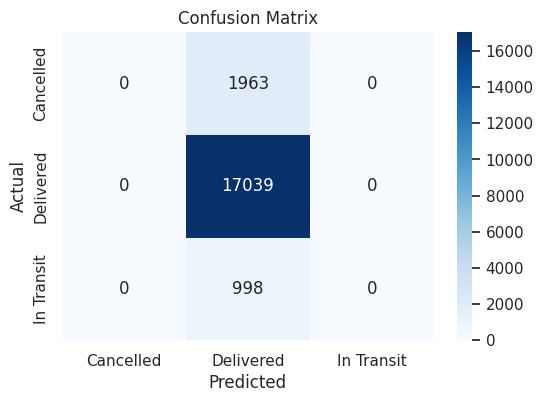

In [54]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Accuracy gives a general sense of performance, but the classification report is more informative.  
Precision answers: when the model predicts a class, how often is it correct?  
Recall answers: out of all real cases of a class, how many did the model find?

The confusion matrix shows which classes the model confuses most often.


## 13. Feature importance (What mattered the most?)

Random Forest provides a built-in feature importance score.  
Because we used one-hot encoding, each categorical value becomes its own feature.  
We will extract the final feature names and plot the top importances.


In [58]:
# Get feature names after preprocessing from model_task1
ohe = model_task1.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model_task1.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)

,feature,importance
44,price_per_item,0.066555
32,Total_Price,0.065836
37,Driver_Lat,0.065821
36,Customer_Lon,0.065700
38,Driver_Lon,0.065516
34,Restaurant_Lon,0.065160
33,Restaurant_Lat,0.065001
35,Customer_Lat,0.064767
46,delivery_speed_expectation,0.062627
45,haversine_rest_to_cust_km,0.061544


### Task 2 Solution: Different Rule for `is_peak_hour`

I will now modify the rule for `is_peak_hour`. The original rule considered lunch (12-15) and dinner (19-23) times. For this task, I'll define peak hours solely as the evening dinner rush, for example, from 18:00 to 22:00 (6 PM to 10 PM).

After redefining `is_peak_hour`, I will re-run the data preparation, model training, and evaluation steps to observe how this change affects the model's performance.

In [ ]:
# Re-initialize df_fe from original df to ensure a clean slate for this task's feature engineering
df_fe = df.copy()
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")

df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([5,6]).astype(int)

# ***TASK 2: Modified peak-hour rule (e.g., evening dinner rush: 18-22)***
df_fe["is_peak_hour"] = df_fe["order_hour"].isin(list(range(18,23))).astype(int)

# Re-add other engineered features from previous steps to maintain consistency for comparison
df_fe["price_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]

# Optional Haversine distance (if columns exist)
coord_cols = {"Restaurant_Lat","Restaurant_Lon","Customer_Lat","Customer_Lon"}
if coord_cols.issubset(set(df_fe.columns)):
    df_fe["haversine_rest_to_cust_km"] = haversine_km(
        df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"],
        df_fe["Customer_Lat"], df_fe["Customer_Lon"]
    )

# Item_Name_reduced (re-apply with original top_k=20 for consistency with initial model)
if "Item_Name" in df_fe.columns:
    top_k = 20
    top_items = df_fe["Item_Name"].value_counts().head(top_k).index
    df_fe["Item_Name_reduced"] = np.where(df_fe["Item_Name"].isin(top_items), df_fe["Item_Name"], "Other")

# price_tier
df_fe["price_tier"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 100, 250, 500, np.inf],
    labels=["low","medium","high","very_high"]
)

print("is_peak_hour distribution with new rule:")
display(df_fe[["order_hour","is_peak_hour"]].head(10))

# Re-prepare features for modeling
drop_cols = [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
    "Order_Time", "Delivery_Time", "Delivery_Duration_Minutes",
    "Item_Name" # we replaced it with Item_Name_reduced
]

drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Re-identify categorical and numerical columns (might have changed if haversine was not added)
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

model_task2 = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

model_task2.fit(X_train, y_train)

y_pred_task2 = model_task2.predict(X_test)

print("\n--- Performance with modified is_peak_hour rule ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred_task2), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_task2))

is_peak_hour distribution with new rule:


,order_hour,is_peak_hour
0,8,0
1,21,1
2,14,0
3,2,0
4,9,0
5,12,0
6,4,0
7,18,1
8,22,1
9,0,0


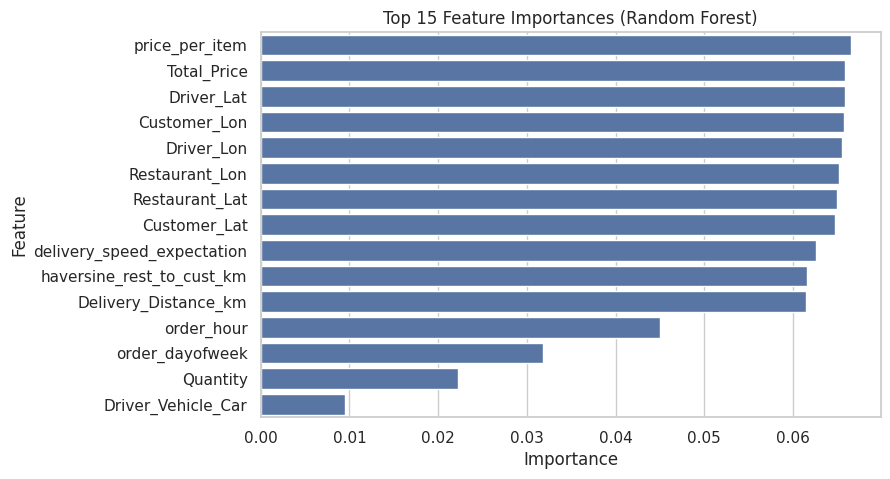

In [59]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


This chart helps us understand which engineered and original features contributed most to predicting `Order_Status`.  
A high importance score suggests the feature provides useful signal, but it does not automatically imply a causal relationship.


## 14. Optional: Feature selection using SelectFromModel

We can select a subset of features using model-based selection.  
This is optional and mainly used to illustrate the concept of feature selection after feature engineering.


In [60]:
from sklearn.feature_selection import SelectFromModel

# Build a new pipeline that selects features based on RF importances
selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"  # keep features above the median importance
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)

print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs))


Accuracy (with feature selection): 0.8519

Classification Report (with feature selection):
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


If performance stays similar, feature selection may help simplify the model with minimal accuracy loss.  
If performance drops, it may indicate that important information was removed.

## 15. Student tasks

### Task 1
Create one new engineered feature that you believe will help predict `Order_Status`.  
Write one paragraph justifying your choice.

### Task 2
Try a different rule for `is_peak_hour` and discuss whether performance changes.

### Task 3
Change `top_k` in `Item_Name_reduced` (for example 10, 30, 50) and compare:
- accuracy
- top feature importances

### Task 4
Run the optional feature selection section and explain whether it was beneficial in your case.


## Wrap-up
In this lab, the dataset was already clean, so our focus was on feature engineering.  
We engineered time-based, price-based, and category-reduction features, then evaluated a baseline classifier and interpreted feature importance.
